In [1]:
#Install dependencies
!pip install stable-baselines3
!pip install 'shimmy>=2.0'
!pip install PyPortfolioOpt
!pip install gym==0.26.2
!pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 17.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 50.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827728 sha256=77b02d4eacd16c89c395820f66e83600c2d9e6bca282fe0c33b3ea2a6854fe2f
  Stored in directory: /root/.cache/pip/wheels/95/51/6c/9bb05ebbe7c5cb8171dfaa3611f32622ca4658d53f31c79077
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is t

In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import time
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from pypfopt import EfficientFrontier, risk_models, expected_returns

# ============ Data Fetching ======================

def fetch_nifty50_historical_data():
    nifty_50_tickers = [
        'ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS',
        'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BPCL.NS', 'BHARTIARTL.NS',
        'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS', 'DIVISLAB.NS', 'DRREDDY.NS',
        'EICHERMOT.NS', 'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS',
        'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'ITC.NS',
        'INDUSINDBK.NS', 'INFY.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LTIM.NS', 'LT.NS',
        'M&M.NS', 'MARUTI.NS', 'NTPC.NS', 'NESTLEIND.NS', 'ONGC.NS',
        'POWERGRID.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SBIN.NS', 'SUNPHARMA.NS',
        'TCS.NS', 'TATACONSUM.NS', 'TATAMOTORS.NS', 'TATASTEEL.NS', 'TECHM.NS',
        'TITAN.NS', 'ULTRACEMCO.NS', 'UPL.NS', 'WIPRO.NS'
    ]

    start_date = '2000-01-01'
    end_date = '2025-01-01'

    all_data_df = pd.DataFrame()
    print(f"Fetching data for {len(nifty_50_tickers)} stocks from {start_date} to {end_date}...")

    for ticker in nifty_50_tickers:
        try:
            stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
            if not stock_data.empty:
                all_data_df[ticker] = stock_data['Close']
            else:
                print(f"Could not fetch data for {ticker}. It might not be listed for the full period.")
        except Exception as e:
            print(f"An error occurred while fetching data for {ticker}: {e}")
        time.sleep(0.5)

    print("\nFetching data for Nifty 50 Index, Gold, and Silver...")
    extra_tickers = {
        '^NSEI': 'NIFTY50_INDEX',
        'GC=F': 'GOLD_USD',
        'SI=F': 'SILVER_USD'
    }

    for ticker, name in extra_tickers.items():
        try:
            data = yf.download(ticker, start=start_date, end=end_date, progress=False)
            if not data.empty:
                all_data_df[name] = data['Close']
            else:
                print(f"Could not fetch data for {name} ({ticker}).")
        except Exception as e:
            print(f"An error occurred while fetching data for {name} ({ticker}): {e}")
        time.sleep(0.5)

    if 'GOLD_USD' in all_data_df.columns:
        all_data_df['GOLD_USD'] = all_data_df['GOLD_USD'].ffill()
    if 'SILVER_USD' in all_data_df.columns:
        all_data_df['SILVER_USD'] = all_data_df['SILVER_USD'].ffill()

    if 'NIFTY50_INDEX' in all_data_df.columns:
        all_data_df.dropna(subset=['NIFTY50_INDEX'], inplace=True)

    cleaned_df = all_data_df.dropna(axis=1, how='any')
    print(f"\nFinal shape of the cleaned DataFrame: {cleaned_df.shape}")

    return cleaned_df

# Execute ingestion
cleaned_df = fetch_nifty50_historical_data()


print("Segregating equity features from macroeconomic benchmarks...")

# Extract the NIFTY 50 benchmark
nifty_data = cleaned_df['NIFTY50_INDEX']

# Isolate the equities by dropping benchmarks/commodities for the environment
non_asset_cols = ['NIFTY50_INDEX', 'GOLD_USD', 'SILVER_USD']
cols_to_drop = [col for col in non_asset_cols if col in cleaned_df.columns]

asset_data = cleaned_df.drop(columns=cols_to_drop)
asset_returns = asset_data.pct_change().dropna()


Fetching data for 50 stocks from 2000-01-01 to 2025-01-01...


/tmp/ipykernel_5920/1797443750.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_5920/1797443750.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_5920/1797443750.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_5920/1797443750.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_5920/1797443750.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/

Could not fetch data for TATAMOTORS.NS. It might not be listed for the full period.


/tmp/ipykernel_5920/1797443750.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_5920/1797443750.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_5920/1797443750.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_5920/1797443750.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_5920/1797443750.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/


Fetching data for Nifty 50 Index, Gold, and Silver...


/tmp/ipykernel_5920/1797443750.py:54: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_5920/1797443750.py:54: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipykernel_5920/1797443750.py:54: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)



Final shape of the cleaned DataFrame: (4238, 46)
Segregating equity features from macroeconomic benchmarks...


Output()

Training PPO Agent...
Using cuda device


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 195      |
|    ep_rew_mean     | -3.03    |
| time/              |          |
|    fps             | 22       |
|    iterations      | 1        |
|    time_elapsed    | 92       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 195         |
|    ep_rew_mean          | -3.06       |
| time/                   |             |
|    fps                  | 21          |
|    iterations           | 2           |
|    time_elapsed         | 186         |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.023055559 |
|    clip_fraction        | 0.131       |
|    clip_range           | 0.2         |
|    entropy_loss         | -61         |
|    explained_variance   | -2.56e-05   |
|    learning_rate        | 0.

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

...

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 195        |
|    ep_rew_mean          | 6.29       |
| time/                   |            |
|    fps                  | 21         |
|    iterations           | 7          |
|    time_elapsed         | 665        |
|    total_timesteps      | 14336      |
| train/                  |            |
|    approx_kl            | 0.05427435 |
|    clip_fraction        | 0.534      |
|    clip_range           | 0.2        |
|    entropy_loss         | -61        |
|    explained_variance   | 0.883      |
|    learning_rate        | 0.0003     |
|    loss                 | 9.14       |
|    n_updates            | 60         |
|    policy_gradient_loss | -0.116     |
|    std                  | 0.998      |
|    value_loss           | 20.5       |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean

Running Backtests...


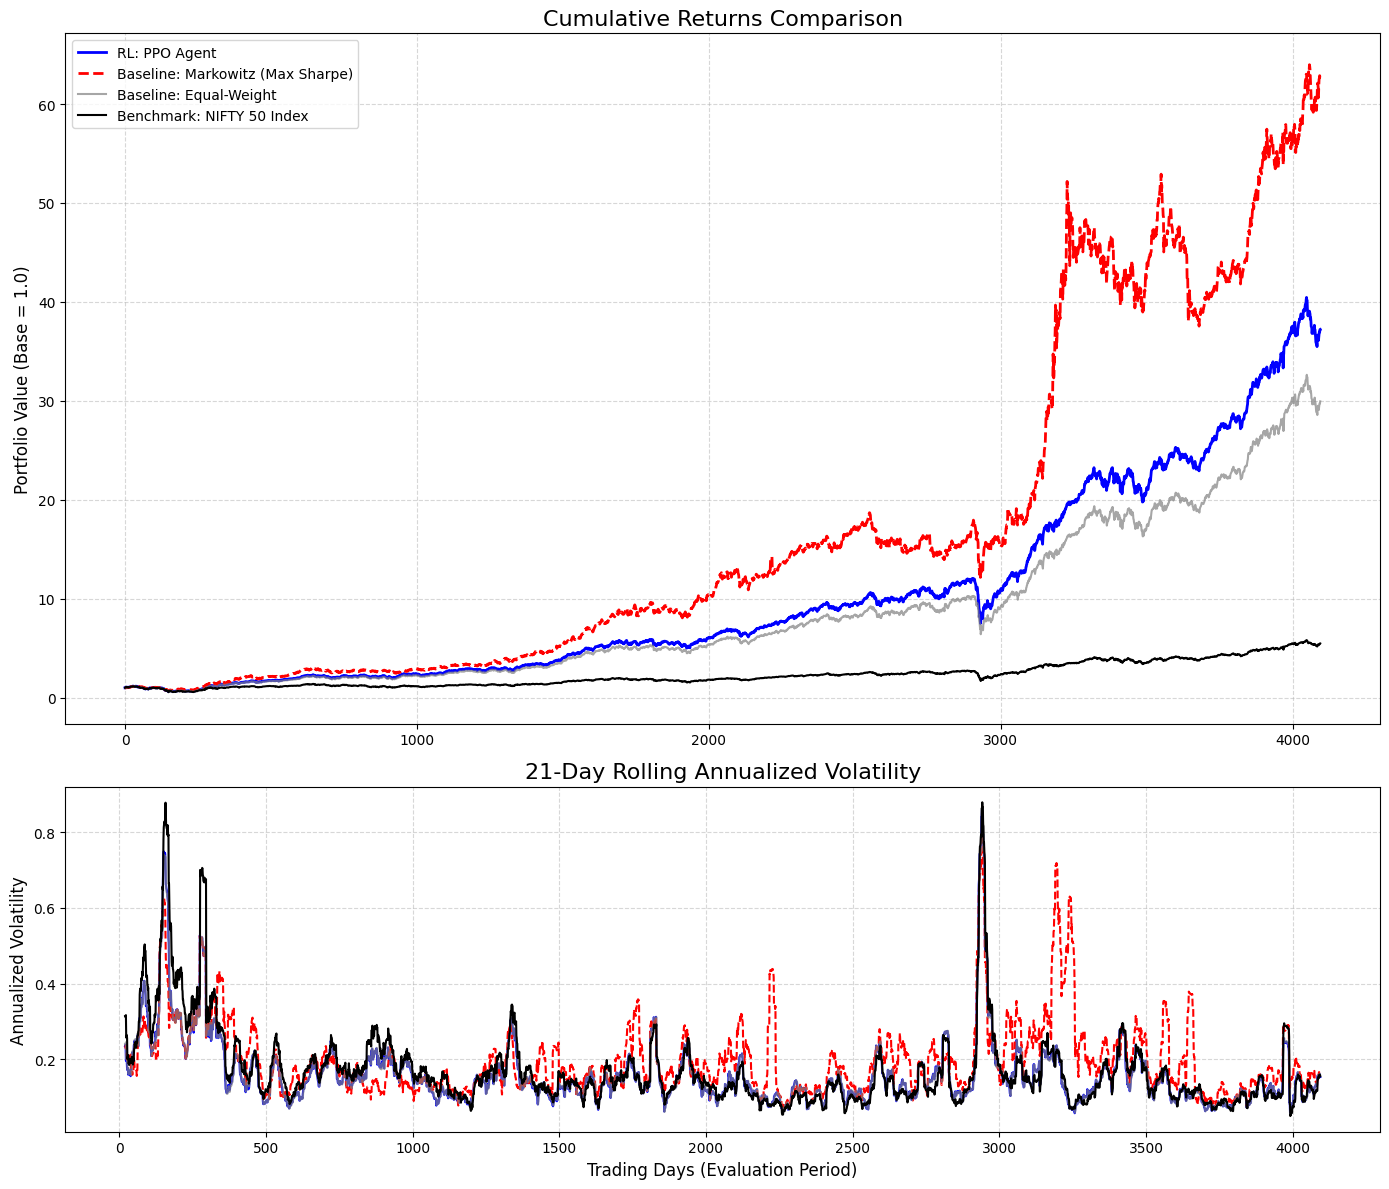

In [15]:
# ========= Gymnasium Environment for RL ======================
class PortfolioEnv(gym.Env):
    def __init__(self, price_df, window_size=126, hold_period=21):
        super().__init__()
        self.price_df = price_df
        self.returns_df = price_df.pct_change().dropna()
        self.window_size = window_size
        self.hold_period = hold_period
        self.num_assets = self.returns_df.shape[1]

        self.observation_space = spaces.Box(
            low=-0.5, high=0.5,
            shape=(self.window_size, self.num_assets),
            dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-3.0, high=3.0,
            shape=(self.num_assets,),
            dtype=np.float32
        )
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.start_idx = 0
        self.end_idx = self.window_size
        return self._get_obs(), {}

    def _get_obs(self):
        obs = self.returns_df.iloc[self.start_idx:self.end_idx].values
        return obs.astype(np.float32)

    def _softmax(self, x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum()

    def sortino_ratio(self, rets):
        if len(rets) < 2: return 0.0
        mean_ret = np.mean(rets)
        downside = rets[rets < 0]
        ds_std = np.std(downside) if len(downside) > 1 else 0.001
        return np.clip((mean_ret / (ds_std + 1e-6)) * np.sqrt(252), -10, 10)

    # def step(self, action):
    #     weights = self._softmax(action)
    #     apply_start = self.end_idx
    #     apply_end = self.end_idx + self.hold_period

    #     if apply_end >= len(self.returns_df):
    #         return self._get_obs(), 0.0, True, False, {}

    #     future_rets = self.returns_df.iloc[apply_start:apply_end].values
    #     port_rets = future_rets @ weights

    #     eq_w = np.ones(self.num_assets) / self.num_assets
    #     eq_rets = future_rets @ eq_w

    #     reward = self.sortino_ratio(port_rets) - self.sortino_ratio(eq_rets) # Reward Function

    #     self.current_step += 1
    #     self.start_idx += self.hold_period
    #     self.end_idx += self.hold_period

    #     done = (self.end_idx + self.hold_period) >= len(self.returns_df)
    #     return self._get_obs(), float(reward), done, False, {}


    # reward function to use the Markowitz Mean-Variance Optimization (MVO) as the baseline (slows training as it has complex quadratic programming solver (the Markowitz optimization) at every single step of every epoch)
    def step(self, action):
        # 1. Agent's Allocation
        weights = self._softmax(action)
        apply_start = self.end_idx
        apply_end = self.end_idx + self.hold_period

        # Check for episode termination
        if apply_end >= len(self.returns_df):
            return self._get_obs(), 0.0, True, False, {}

        # Calculate Agent's Realized Returns
        future_rets = self.returns_df.iloc[apply_start:apply_end].values
        port_rets = future_rets @ weights

        # 2. Markowitz (MVO) Baseline Allocation
        try:
            # Use the exact same lookback window the RL agent sees
            price_window = self.price_df.iloc[self.start_idx:self.end_idx]

            mu = expected_returns.mean_historical_return(price_window)
            S = risk_models.sample_cov(price_window)
            ef = EfficientFrontier(mu, S)

            # Solve for Max Sharpe
            mvo_weights_dict = ef.max_sharpe()
            mvo_weights = np.array([mvo_weights_dict.get(t, 0) for t in self.price_df.columns])
        except Exception:
            # Fallback to equal weight if optimization fails (e.g., non-positive definite matrix)
            mvo_weights = np.ones(self.num_assets) / self.num_assets

        # Calculate MVO's Realized Returns
        mvo_rets = future_rets @ mvo_weights

        # 3. Reward Calculation: Agent Sortino vs MVO Sortino
        reward = self.sortino_ratio(port_rets) - self.sortino_ratio(mvo_rets)

        # 4. Advance Environment State
        self.current_step += 1
        self.start_idx += self.hold_period
        self.end_idx += self.hold_period

        done = (self.end_idx + self.hold_period) >= len(self.returns_df)
        return self._get_obs(), float(reward), done, False, {}



# ======= Training the RL Agent ==================
print("Training PPO Agent...")
env_train = make_vec_env(lambda: PortfolioEnv(asset_data), n_envs=1)

# verbose=1 prints detailed metrics (reward, loss, etc.) to the console.
# If you only want the visual loading bar, you can change this back to verbose=0.
model = PPO("MlpPolicy", env_train, verbose=1, gamma=0.99)

# progress_bar=True adds a real-time visual loading bar (requires tqdm)
model.learn(total_timesteps=15000, progress_bar=True)


# ========= Evaluation Functions (Returning Daily Returns) ======================

def get_rl_daily_returns(model, price_df, window_size=126, hold_period=21):
    test_env = PortfolioEnv(price_df, window_size, hold_period)
    obs, _ = test_env.reset()
    daily_rets = []
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        weights = test_env._softmax(action)

        start = test_env.end_idx
        end = min(start + test_env.hold_period, len(test_env.returns_df))
        realized_returns = test_env.returns_df.iloc[start:end].values @ weights
        daily_rets.extend(realized_returns)

        obs, _, done, _, _ = test_env.step(action)

    return pd.Series(daily_rets)

def get_markowitz_daily_returns(price_df, returns_df, window_size=126, hold_period=21):
    daily_rets = []
    num_assets = price_df.shape[1]

    for i in range(window_size, len(price_df) - hold_period, hold_period):
        window = price_df.iloc[i - window_size : i]
        try:
            mu = expected_returns.mean_historical_return(window)
            S = risk_models.sample_cov(window)
            ef = EfficientFrontier(mu, S)
            weights_dict = ef.max_sharpe()
            weights = np.array([weights_dict.get(t, 0) for t in price_df.columns])
        except Exception:
            # Fallback to Equal Weight if optimization fails
            weights = np.ones(num_assets) / num_assets

        # FIX: Use the globally calculated returns_df to avoid dropping days
        future_returns = returns_df.iloc[i : i + hold_period]
        realized_returns = future_returns @ weights
        daily_rets.extend(realized_returns.values)

    return pd.Series(daily_rets)

# When you call it, pass BOTH asset_data and asset_returns:
# mvo_rets = get_markowitz_daily_returns(asset_data, asset_returns)

# ==========Execute Backtests & Align Data======================

print("Running Backtests...")
rl_rets = get_rl_daily_returns(model, asset_data)

# FIX: Pass both asset_data and asset_returns to the MVO function
mvo_rets = get_markowitz_daily_returns(asset_data, asset_returns)

# Determine the exact length of the simulated period
sim_length = len(rl_rets)

# Generate Equal Weight returns for the exact same length
eq_w = np.ones(asset_data.shape[1]) / asset_data.shape[1]
eq_rets = pd.Series((asset_returns.iloc[125:125+sim_length].values @ eq_w))

# Generate NIFTY 50 returns for the exact same length
nifty_series = nifty_data.pct_change().dropna().iloc[125:125+sim_length]
nifty_rets = pd.Series(nifty_series.values)

# Build a DataFrame for easy metric calculation
results_df = pd.DataFrame({
    "PPO (RL)": rl_rets,
    "Markowitz (MVO)": mvo_rets,
    "Equal-Weight": eq_rets,
    "NIFTY 50": nifty_rets
})

# ========== Calculate Metrics & Plot ======================
# Cumulative Returns: (1 + r).cumprod()
cum_returns = (1 + results_df).cumprod()

# Rolling Volatility: 21-day rolling standard deviation, annualized (sqrt(252))
rolling_vol = results_df.rolling(window=21).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1]})

# Plot 1: Cumulative Returns
axes[0].plot(cum_returns["PPO (RL)"], label="RL: PPO Agent", color='blue', linewidth=2)
axes[0].plot(cum_returns["Markowitz (MVO)"], label="Baseline: Markowitz (Max Sharpe)", color='red', linestyle="--", linewidth=2)
axes[0].plot(cum_returns["Equal-Weight"], label="Baseline: Equal-Weight", color='gray', alpha=0.7)
axes[0].plot(cum_returns["NIFTY 50"], label="Benchmark: NIFTY 50 Index", color='black', linewidth=1.5)

axes[0].set_title("Cumulative Returns Comparison", fontsize=16)
axes[0].set_ylabel("Portfolio Value (Base = 1.0)", fontsize=12)
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Rolling Volatility
axes[1].plot(rolling_vol["PPO (RL)"], color='blue', linewidth=1.5)
axes[1].plot(rolling_vol["Markowitz (MVO)"], color='red', linestyle="--", linewidth=1.5)
axes[1].plot(rolling_vol["Equal-Weight"], color='gray', alpha=0.7)
axes[1].plot(rolling_vol["NIFTY 50"], color='black', linewidth=1.5)

axes[1].set_title("21-Day Rolling Annualized Volatility", fontsize=16)
axes[1].set_xlabel("Trading Days (Evaluation Period)", fontsize=12)
axes[1].set_ylabel("Annualized Volatility", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [16]:
#======= Calculates Perfomance Metrices ==========
def calculate_performance_metrics(results_df, benchmark_col="NIFTY 50", risk_free_rate=0.05):
    """
    Computes a comprehensive suite of quantitative performance metrics for a dataframe of daily returns.
    """
    metrics = {}
    TRADING_DAYS = 252 # Standard NSE trading days in a year

    # Extract benchmark series for relative metrics
    bench_rets = results_df[benchmark_col]
    bench_ann_ret = (1 + bench_rets).prod() ** (TRADING_DAYS / len(bench_rets)) - 1

    for col in results_df.columns:
        rets = results_df[col]

        # 1. Absolute Returns
        cum_ret = (1 + rets).prod() - 1
        ann_ret = (1 + cum_ret) ** (TRADING_DAYS / len(rets)) - 1

        # 2. Volatility
        ann_vol = rets.std() * np.sqrt(TRADING_DAYS)

        # 3. Risk-Adjusted Ratios
        sharpe = (ann_ret - risk_free_rate) / ann_vol if ann_vol != 0 else np.nan

        downside_rets = rets[rets < 0]
        downside_vol = downside_rets.std() * np.sqrt(TRADING_DAYS)
        sortino = (ann_ret - risk_free_rate) / downside_vol if downside_vol != 0 else np.nan

        # 4. Drawdown Calculations
        cum_idx = (1 + rets).cumprod()
        peaks = cum_idx.cummax()
        drawdowns = (cum_idx - peaks) / peaks

        avg_dd = drawdowns.mean()
        max_dd = drawdowns.min()

        calmar = (ann_ret - risk_free_rate) / abs(max_dd) if max_dd != 0 else np.nan

        # 5. Benchmark-Relative Metrics
        if col == benchmark_col:
            beta = 1.0
            alpha = 0.0
            info_ratio = np.nan
        else:
            # FIX: Align the two series and drop any residual NaNs before covariance
            aligned_data = pd.concat([rets, bench_rets], axis=1).dropna()
            aligned_rets = aligned_data.iloc[:, 0]
            aligned_bench = aligned_data.iloc[:, 1]

            # Beta
            if len(aligned_data) > 1:
                covariance = np.cov(aligned_rets, aligned_bench)[0, 1]
                bench_var = np.var(aligned_bench)
                beta = covariance / bench_var if bench_var != 0 else np.nan
            else:
                beta = np.nan

            # Jensen's Alpha (Annualized)
            alpha = ann_ret - (risk_free_rate + beta * (bench_ann_ret - risk_free_rate))

            # Information Ratio
            active_rets = rets - bench_rets
            tracking_error = active_rets.std() * np.sqrt(TRADING_DAYS)
            info_ratio = (ann_ret - bench_ann_ret) / tracking_error if tracking_error != 0 else np.nan

        # Store metrics in dictionary
        metrics[col] = {
            "Cumulative Return (%)": cum_ret * 100,
            "Annual Return (CAGR) (%)": ann_ret * 100,
            "Volatility (Ann. Std. Dev) (%)": ann_vol * 100,
            "Sharpe Ratio": sharpe,
            "Sortino Ratio": sortino,
            "Calmar Ratio": calmar,
            "Average Drawdown (%)": avg_dd * 100,
            "Max Drawdown (%)": max_dd * 100,
            "Alpha (Ann. %)": alpha * 100,
            "Beta": beta,
            "Information Ratio": info_ratio
        }

    # Convert to DataFrame for a clean tabular view
    metrics_df = pd.DataFrame(metrics).round(4)
    return metrics_df

# Execute and display the results
performance_summary = calculate_performance_metrics(results_df, benchmark_col="NIFTY 50", risk_free_rate=0.05)
print("\n--- Portfolio Performance Comparison ---")
display(performance_summary)


--- Portfolio Performance Comparison ---


,PPO (RL),Markowitz (MVO),Equal-Weight,NIFTY 50
Cumulative Return (%),3622.1667,6178.0277,2895.1595,448.6976
Annual Return (CAGR) (%),24.9293,29.0135,23.2698,11.0446
Volatility (Ann. Std. Dev) (%),18.5664,22.4018,18.5704,20.3606
Sharpe Ratio,1.0734,1.0719,0.9838,0.2969
Sortino Ratio,1.3923,1.4559,1.2768,0.3878
Calmar Ratio,0.4188,0.6238,0.3785,0.1169
Average Drawdown (%),-4.8804,-8.6537,-5.1349,-7.9481
Max Drawdown (%),-47.5818,-38.4957,-48.2698,-51.7195
Alpha (Ann. %),19.5802,23.7285,13.0208,0.0000
Beta,0.0578,0.0472,0.8684,1.0000
